In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [66]:
file = '/Users/cream/Downloads/cleaned_books_data.xls'
data = pd.read_csv(file)
data['ratings_count'] = pd.to_numeric(data['ratings_count'], errors='coerce')
data['goodreads_rating'] = data['goodreads_rating'].str.extract(r'(\d+\.\d+)').astype(float)

### The charts represent the trending books by year

In [204]:
#Find the trending books
trending_data = ['title', 'author', 'first_publish_year', 'goodreads_rating', 'subjects','ratings_count']
trending_data = data[trending_data]
rating = trending_data[trending_data['ratings_count'] > 5000]
rating.sort_values('ratings_count', ascending = False)
sort_ratingcount_byrate = rating[rating['goodreads_rating'] > 4.00]
#grouping the books by years
books_1900_and_older = sort_ratingcount_byrate[sort_ratingcount_byrate['first_publish_year'] <= 1900]

books_1900_to_1920 = sort_ratingcount_byrate[
    (sort_ratingcount_byrate['first_publish_year'] >= 1900) & 
    (sort_ratingcount_byrate['first_publish_year'] <= 1920)
]
books_1921_to_1940 = sort_ratingcount_byrate[
    (sort_ratingcount_byrate['first_publish_year'] >= 1921) & 
    (sort_ratingcount_byrate['first_publish_year'] <= 1940)
]
books_1941_to_1960 = sort_ratingcount_byrate[
    (sort_ratingcount_byrate['first_publish_year'] >= 1941) & 
    (sort_ratingcount_byrate['first_publish_year'] <= 1960)
]
books_1961_to_1980 = sort_ratingcount_byrate[
    (sort_ratingcount_byrate['first_publish_year'] >= 1961) & 
    (sort_ratingcount_byrate['first_publish_year'] <= 1980)
]
books_1981_to_2000 = sort_ratingcount_byrate[
    (sort_ratingcount_byrate['first_publish_year'] >= 1981) & 
    (sort_ratingcount_byrate['first_publish_year'] <= 2000)
]
books_2001_to_older = sort_ratingcount_byrate[
    (sort_ratingcount_byrate['first_publish_year'] >= 2001)
]

In [206]:
#count
group_counts = {
    '1900 and older': len(books_1900_and_older),
    '1900-1920': len(books_1900_to_1920),
    '1921-1940': len(books_1921_to_1940),
    '1941-1960': len(books_1941_to_1960),
    '1961-1980': len(books_1961_to_1980),
    '1981-2000': len(books_1981_to_2000),
    '2001 and newer': len(books_2001_to_older),
}
count_table = pd.DataFrame(list(group_counts.items()), columns=['Year Range', 'Count'])
print(count_table)

       Year Range  Count
0  1900 and older     24
1       1900-1920     19
2       1921-1940     13
3       1941-1960     36
4       1961-1980     18
5       1981-2000     24
6  2001 and newer     13


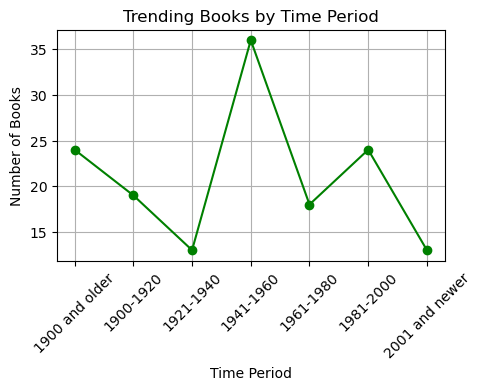

In [208]:
# line graph
plt.figure(figsize=(5, 3))
plt.plot(group_counts.keys(), group_counts.values(), marker='o', color='green', linestyle='-')
plt.title('Trending Books by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### The popular genre of books in different years

In [242]:
data_1900_older = trending_data[trending_data['first_publish_year'] <= 1900]
data_1901_1920 = trending_data[
(trending_data['first_publish_year'] >= 1901) &
(trending_data['first_publish_year'] <= 1920)
]
data_1901_1920 = trending_data[
(trending_data['first_publish_year'] >= 1901) &
(trending_data['first_publish_year'] <= 1920)
]
data_1921_1940 = trending_data[
(trending_data['first_publish_year'] >= 1921) &
(trending_data['first_publish_year'] <= 1940)
]
data_1941_1960 = trending_data[
(trending_data['first_publish_year'] >= 1941) &
(trending_data['first_publish_year'] <= 1960)
]
data_1961_1980 = trending_data[
(trending_data['first_publish_year'] >= 1961) &
(trending_data['first_publish_year'] <= 1980)
]
data_1981_2000 = trending_data[
(trending_data['first_publish_year'] >= 1981) &
(trending_data['first_publish_year'] <= 2000)
]
data_2001_newer = trending_data[(trending_data['first_publish_year'] >= 2001)]

In [247]:
# Find rows containing a specific word
fiction = trending_data[trending_data['subjects'].str.contains('fiction', case=False, na=False)]
romance = trending_data[trending_data['subjects'].str.contains('romance', case=False, na=False)]
horror = trending_data[trending_data['subjects'].str.contains('horror', case=False, na=False)]
crime = trending_data[trending_data['subjects'].str.contains('crime', case=False, na=False)]
comedy = trending_data[trending_data['subjects'].str.contains('comedy', case=False, na=False)]

In [257]:
#genre based on year
genre_1900_older = {
    'fiction': len(data_1900_older[data_1900_older['subjects'].str.contains('fiction', case=False, na=False)]),
    'romance': len(data_1900_older[data_1900_older['subjects'].str.contains('romance', case=False, na=False)]),
    'horror': len(data_1900_older[data_1900_older['subjects'].str.contains('horror', case=False, na=False)]),
    'crime': len(data_1900_older[data_1900_older['subjects'].str.contains('crime', case=False, na=False)]),
    'comedy': len(data_1900_older[data_1900_older['subjects'].str.contains('comedy', case=False, na=False)])
}
genre_1901_1920 = {
    'fiction': len(data_1901_1920[data_1901_1920['subjects'].str.contains('fiction', case=False, na=False)]),
    'romance': len(data_1901_1920[data_1901_1920['subjects'].str.contains('romance', case=False, na=False)]),
    'horror': len(data_1901_1920[data_1901_1920['subjects'].str.contains('horror', case=False, na=False)]),
    'crime': len(data_1901_1920[data_1901_1920['subjects'].str.contains('crime', case=False, na=False)]),
    'comedy': len(data_1901_1920[data_1901_1920['subjects'].str.contains('comedy', case=False, na=False)])
}
genre_1921_1940 = {
    'fiction': len(data_1921_1940[data_1921_1940['subjects'].str.contains('fiction', case=False, na=False)]),
    'romance': len(data_1921_1940[data_1921_1940['subjects'].str.contains('romance', case=False, na=False)]),
    'horror': len(data_1921_1940[data_1921_1940['subjects'].str.contains('horror', case=False, na=False)]),
    'crime': len(data_1921_1940[data_1921_1940['subjects'].str.contains('crime', case=False, na=False)]),
    'comedy': len(data_1921_1940[data_1921_1940['subjects'].str.contains('comedy', case=False, na=False)])
}

genre_1941_1960 = {
    'fiction': len(data_1941_1960[data_1941_1960['subjects'].str.contains('fiction', case=False, na=False)]),
    'romance': len(data_1941_1960[data_1941_1960['subjects'].str.contains('romance', case=False, na=False)]),
    'horror': len(data_1941_1960[data_1941_1960['subjects'].str.contains('horror', case=False, na=False)]),
    'crime': len(data_1941_1960[data_1941_1960['subjects'].str.contains('crime', case=False, na=False)]),
    'comedy': len(data_1941_1960[data_1941_1960['subjects'].str.contains('comedy', case=False, na=False)])
}
genre_1961_1980 = {
    'fiction': len(data_1961_1980[data_1961_1980['subjects'].str.contains('fiction', case=False, na=False)]),
    'romance': len(data_1961_1980[data_1961_1980['subjects'].str.contains('romance', case=False, na=False)]),
    'horror': len(data_1961_1980[data_1961_1980['subjects'].str.contains('horror', case=False, na=False)]),
    'crime': len(data_1961_1980[data_1961_1980['subjects'].str.contains('crime', case=False, na=False)]),
    'comedy': len(data_1961_1980[data_1961_1980['subjects'].str.contains('comedy', case=False, na=False)])
}
genre_1981_2000 = {
    'fiction': len(data_1981_2000[data_1981_2000['subjects'].str.contains('fiction', case=False, na=False)]),
    'romance': len(data_1981_2000[data_1981_2000['subjects'].str.contains('romance', case=False, na=False)]),
    'horror': len(data_1981_2000[data_1981_2000['subjects'].str.contains('horror', case=False, na=False)]),
    'crime': len(data_1981_2000[data_1981_2000['subjects'].str.contains('crime', case=False, na=False)]),
    'comedy': len(data_1981_2000[data_1981_2000['subjects'].str.contains('comedy', case=False, na=False)])
}
genre_2001_newer = {
    'fiction': len(data_2001_newer[data_2001_newer['subjects'].str.contains('fiction', case=False, na=False)]),
    'romance': len(data_2001_newer[data_2001_newer['subjects'].str.contains('romance', case=False, na=False)]),
    'horror': len(data_2001_newer[data_2001_newer['subjects'].str.contains('horror', case=False, na=False)]),
    'crime': len(data_2001_newer[data_2001_newer['subjects'].str.contains('crime', case=False, na=False)]),
    'comedy': len(data_2001_newer[data_2001_newer['subjects'].str.contains('comedy', case=False, na=False)])
}
genre_table = pd.DataFrame({
    'Genre': list(genre_1900_older.keys()),
    '1900-older':list(genre_1900_older.values()),
    '1901-1920':list(genre_1901_1920.values()),
    '1921-1940':list(genre_1921_1940.values()),
    '1941-1960':list(genre_1941_1960.values()),
    '1961-1980': list(genre_1961_1980.values()),
    '1981-2000': list(genre_1981_2000.values()),
    '2001-present': list(genre_2001_newer.values())
})
genre_table

,Genre,1900-older,1901-1920,1921-1940,1941-1960,1961-1980,1981-2000,2001-present
0,fiction,269,80,110,122,111,124,62
1,romance,78,18,17,17,9,18,6
2,horror,22,6,6,8,15,24,12
3,crime,13,3,16,9,5,13,2
4,comedy,13,0,0,1,1,0,1


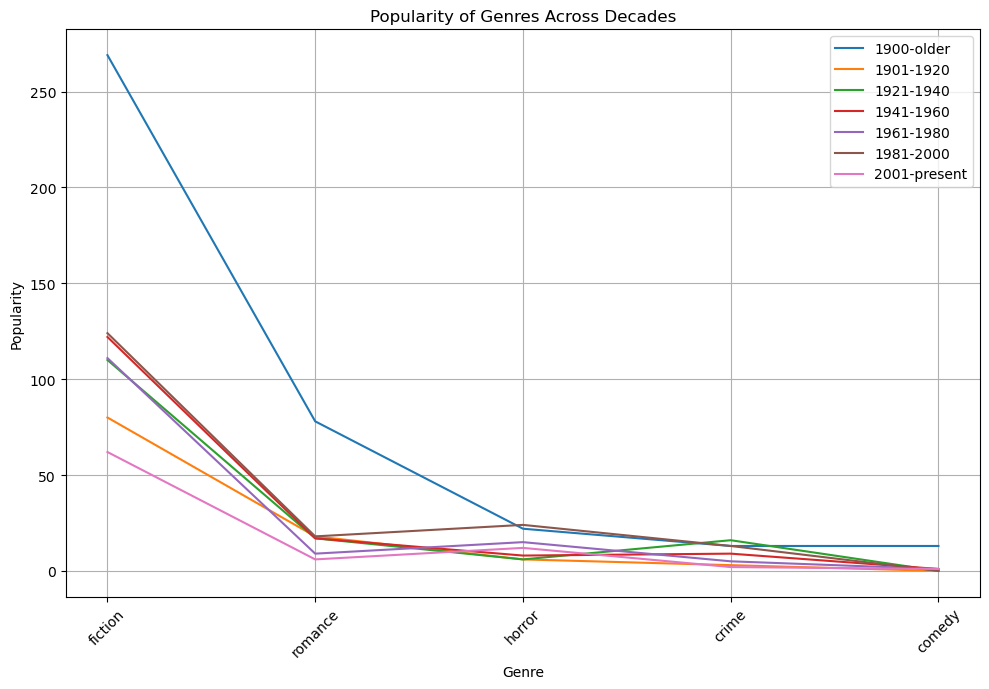

In [259]:
plt.figure(figsize=(10, 7))
for col in genre_table.columns[1:]:
  plt.plot(genre_table['Genre'], genre_table[col], label=col)

# Customize plot
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.title('Popularity of Genres Across Decades')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Display plot
plt.show()